# Notebook 01 — Exploration des données financières DJIA

**Objectif** : Télécharger les prix des 30 actions du DJIA, calculer les rendements log, et analyser les corrélations qui serviront de base au graphe financier.

**Concepts clés** :
- Rendement log : `r_t = ln(P_t / P_{t-1})` — additivité temporelle, distribution proche normale
- Volatilité annualisée : `σ_annuelle = σ_journalière × √252`
- Sharpe ratio : `(μ / σ) × √252` — rendement ajusté du risque
- Corrélation de Pearson : base de construction du graphe

**Référence** : Survey AI in Quant Investment (arXiv 2025) — Section 3.1 Data Processing

In [ ]:
# ─── Imports ────────────────────────────────────────────────────────────────
import sys
import os

# Ajouter le dossier racine du projet au path Python
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

from src.data_loader import DataLoader, DJIA_TICKERS, DJIA_SECTORS

print(f"Tickers disponibles : {len(DJIA_TICKERS)}")
print(DJIA_TICKERS)

Tickers disponibles : 30
['AAPL', 'AMGN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'DOW', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'PG', 'TRV', 'UNH', 'V', 'VZ', 'WBA', 'WMT']


## 1. Téléchargement des données

On utilise `yfinance` pour obtenir les prix de clôture **ajustés** (auto_adjust=True), ce qui corrige automatiquement les dividendes et les splits d'actions.

**Période choisie** : 2018-2023, soit ~5 ans incluant :
- Un marché haussier (2019)
- Le crash COVID-19 (mars 2020)
- La reprise rapide (2020-2021)
- La période inflationniste et la hausse des taux (2022-2023)

In [4]:
# ─── Instanciation du DataLoader ────────────────────────────────────────────
loader = DataLoader(
    tickers = DJIA_TICKERS,
    start   = '2018-01-01',
    end     = '2023-12-31',
)

# Téléchargement
prices, returns = loader.load_djia()

# Aperçu
print("\n── Prix (5 premières lignes) ──")
print(prices.head())

print("\n── Rendements log (5 premières lignes) ──")
print(returns.head())

print(f"\nNombre de jours de trading : {len(prices)}")
print(f"Nombre d'actifs : {len(prices.columns)}")

[DataLoader] Téléchargement de 30 tickers (2018-01-01 → 2023-12-31)...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}
$WBA: possibly delisted; no timezone found

1 Failed download:
['WBA']: possibly delisted; no timezone found


[DataLoader] Suppression de ['DOW', 'WBA'] (trop de NaN)
[DataLoader] ✓ 1509 jours × 28 actifs chargés
[DataLoader] ✓ Rendements (log) calculés : (1508, 28)

── Prix (5 premières lignes) ──
Ticker           AAPL        AMGN        AXP          BA         CAT  \
Date                                                                   
2018-01-02  40.304188  137.775146  88.571541  282.886414  131.543839   
2018-01-03  40.297161  140.374985  89.117615  283.801270  131.744873   
2018-01-04  40.484325  139.783432  90.599930  282.724396  133.554199   
2018-01-05  40.945259  140.616287  90.806549  294.322296  135.665054   
2018-01-08  40.793182  140.577362  89.971077  295.570770  139.074280   

Ticker             CRM       CSCO        CVX         DIS          GS  ...  \
Date                                                                  ...   
2018-01-02  103.156616  30.433550  89.452370  106.224525  213.144287  ...   
2018-01-03  104.026054  30.676334  90.104431  106.680588  211.160110  ... 

## 2. Statistiques descriptives

**À observer** :
- Les actifs tech (AAPL, MSFT) ont généralement les meilleurs Sharpe ratios
- La kurtosis excède systématiquement 3 (queues épaisses = "fat tails")
- La skewness négative indique que les chutes sont plus sévères que les hausses

Ces propriétés justifient d'aller au-delà de la moyenne-variance classique.

In [5]:
stats = loader.descriptive_stats()

print("── Top 10 actifs par Sharpe Ratio ──")
print(stats.nlargest(10, 'Sharpe (rf=0)').to_string())

print("\n── Statistiques globales ──")
print(stats[['Rendement annualisé (%)', 'Volatilité annualisée (%)', 
             'Sharpe (rf=0)']].describe().round(3))

── Top 10 actifs par Sharpe Ratio ──
        Rendement annualisé (%)  Volatilité annualisée (%)  Sharpe (rf=0)  Skewness  Kurtosis excès  Rendement cumulé (×)        Secteur
Ticker                                                                                                                                  
MSFT                      25.82                      30.13          0.857    -0.234           6.884                 3.567     Technology
AAPL                      25.96                      31.69          0.819    -0.245           5.080                 3.495     Technology
MRK                       14.91                      22.59          0.660    -0.257           6.490                 2.094     Healthcare
UNH                       15.97                      28.61          0.558    -0.477          14.586                 2.031     Healthcare
V                         14.41                      27.57          0.523    -0.062           9.099                 1.886     Financials
PG  

## 3. Visualisation des prix normalisés

En normalisant à 100 au départ, on compare les **performances relatives**.
Les couleurs distinguent les secteurs — on voit clairement la divergence Tech vs. Énergie.

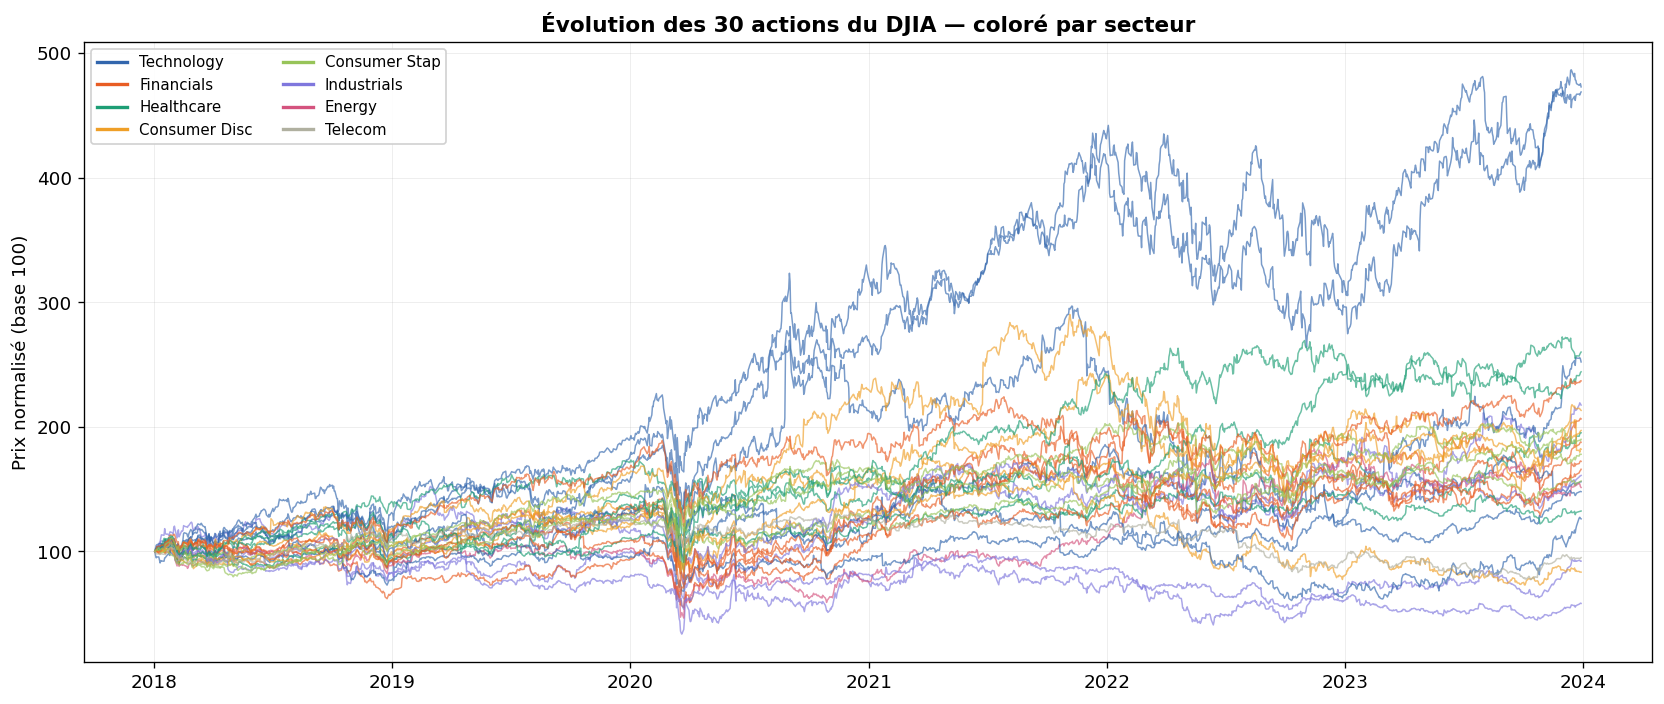

In [9]:
fig = loader.plot_prices(normalize=True)
plt.savefig('../data/01_prix_normalises.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Distribution des rendements

**Pourquoi les rendements log ?**
- `r_t = ln(P_t / P_{t-1})` est **additive** dans le temps : le rendement sur 2 jours = r_1 + r_2
- La distribution est plus proche de la normale (propriété utile pour Markowitz)
- La courbe en cloche avec queues épaisses est caractéristique des marchés financiers

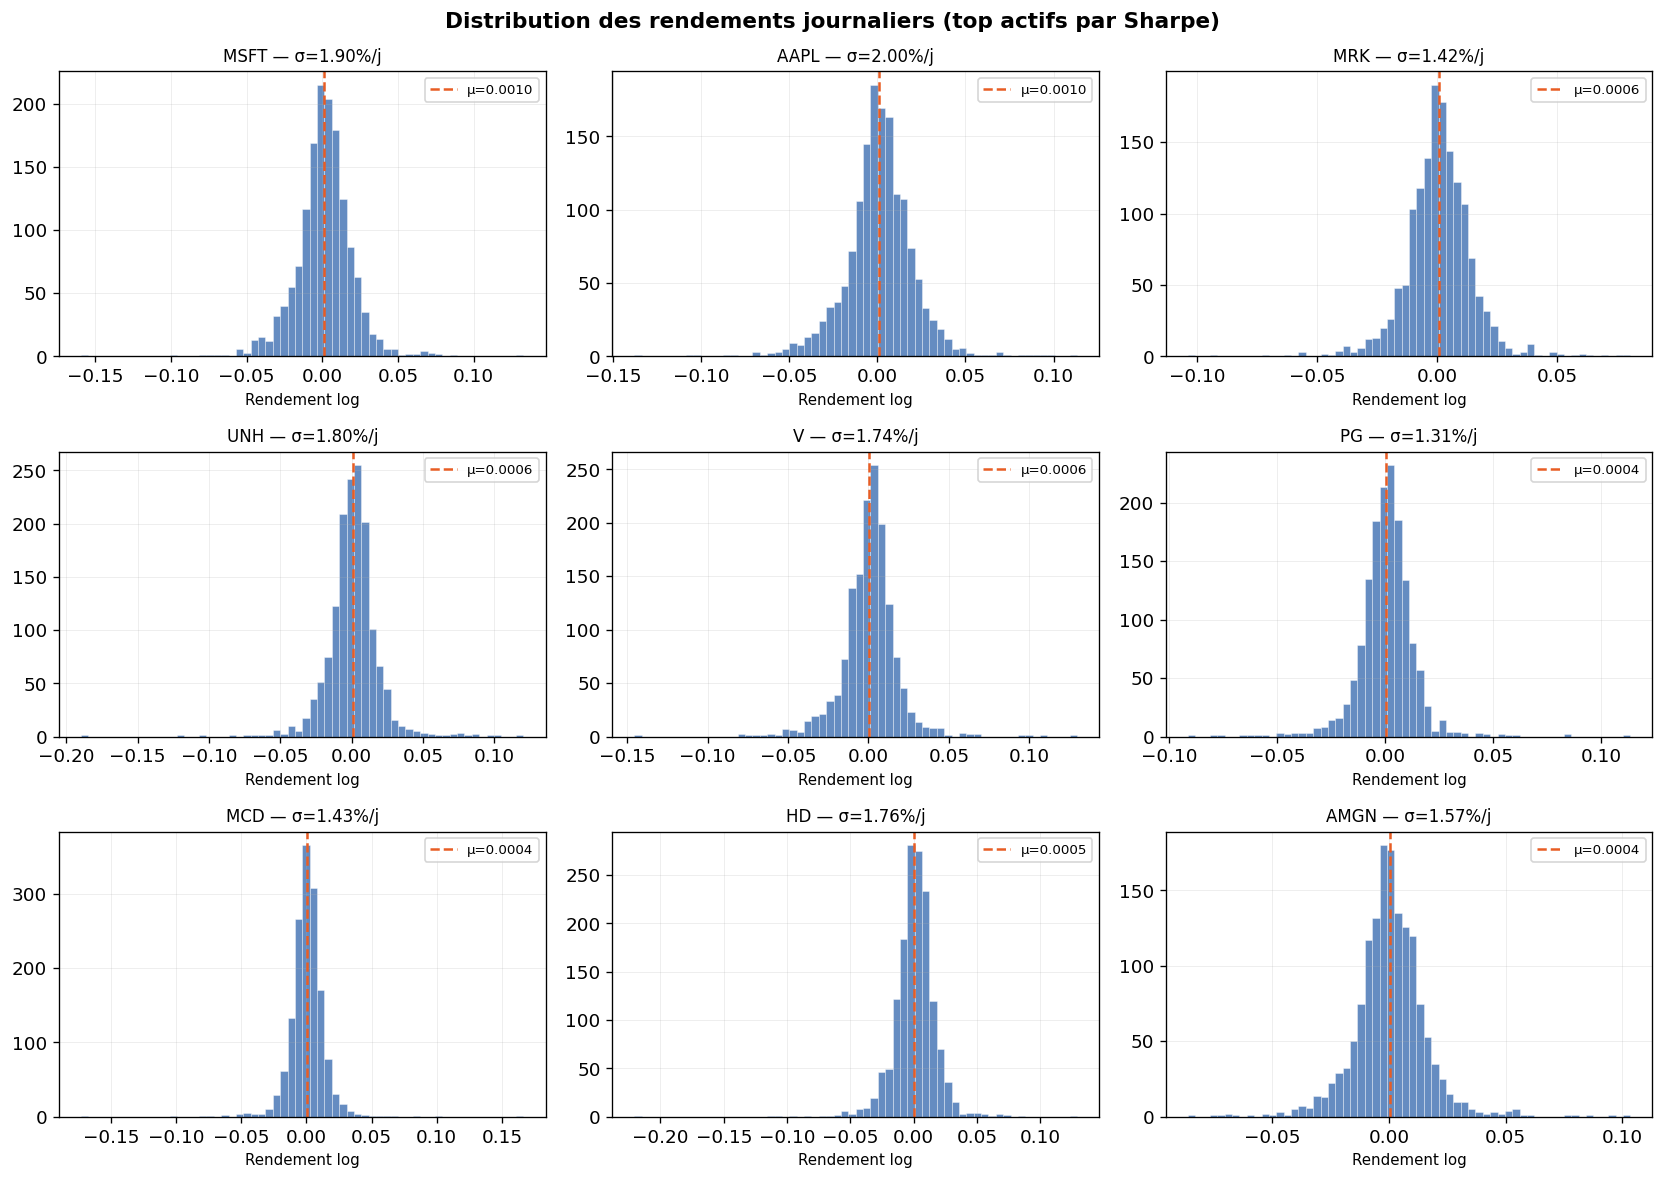

In [10]:
fig = loader.plot_returns_distribution(top_n=9)
plt.savefig('../data/02_distributions_rendements.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Matrice de corrélation — structure du futur graphe

**Insight clé** : les **blocs rouges** sur la diagonale révèlent des corrélations fortes **intra-secteur**.

C'est exactement ce que le GNN va apprendre à exploiter :
- Un actif tech qui surperforme → signal positif pour les autres actifs tech
- La corrélation inter-secteur (hors-diagonale) est plus faible → opportunité de diversification

Le **seuil de corrélation** pour créer une arête dans le graphe sera fixé à `|ρ| > 0.3` (étape 2).

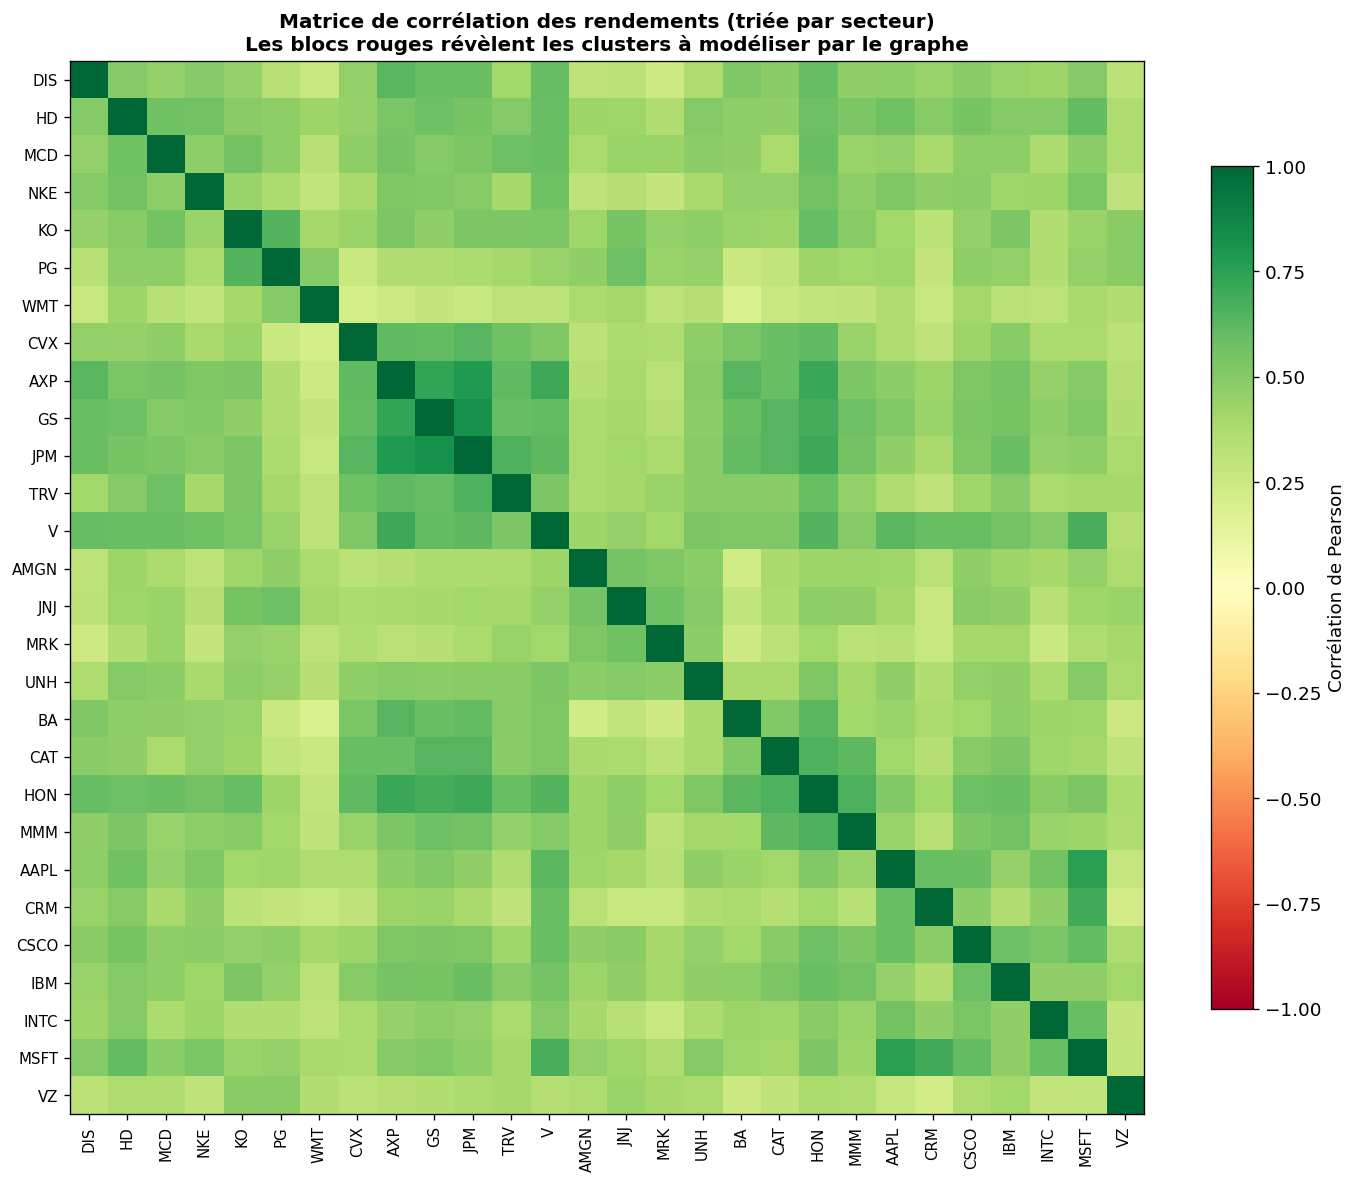

Corrélation moyenne (paires) : 0.455
Corrélation médiane          : 0.456
% paires > 0.3               : 92.6%
% paires > 0.5               : 33.1%


In [11]:
fig = loader.plot_correlation_heatmap()
plt.savefig('../data/03_heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistiques sur la matrice de corrélation
corr_matrix = returns.corr()
upper_tri = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]

print(f"Corrélation moyenne (paires) : {upper_tri.mean():.3f}")
print(f"Corrélation médiane          : {np.median(upper_tri):.3f}")
print(f"% paires > 0.3               : {(upper_tri > 0.3).mean()*100:.1f}%")
print(f"% paires > 0.5               : {(upper_tri > 0.5).mean()*100:.1f}%")

## 6. Sauvegarde pour la suite

On sauvegarde les données au format Parquet (rapide, compact) pour les notebooks suivants.

In [ ]:
# Sauvegarder prices et returns
prices.to_parquet('../data/prices.parquet')
returns.to_parquet('../data/returns.parquet')

# Sauvegarder la matrice de corrélation
corr_matrix.to_parquet('../data/correlation_matrix.parquet')

print("✓ Données sauvegardées dans data/")
print(f"  - prices.parquet       : {prices.shape}")
print(f"  - returns.parquet      : {returns.shape}")
print(f"  - correlation_matrix   : {corr_matrix.shape}")

print("\n══ Résumé pour le notebook 02 ══")
print(f"Période    : {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"Actifs     : {list(returns.columns)}")
print(f"N actifs   : {returns.shape[1]}")
print(f"N jours    : {returns.shape[0]}")

✓ Données sauvegardées dans data/
  - prices.parquet       : (1509, 28)
  - returns.parquet      : (1508, 28)
  - correlation_matrix   : (28, 28)

══ Résumé pour le notebook 02 ══
Période    : 2018-01-03 → 2023-12-29
Actifs     : ['AAPL', 'AMGN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'PG', 'TRV', 'UNH', 'V', 'VZ', 'WMT']
N actifs   : 28
N jours    : 1508

Prochaine étape : 02_graph_construction.ipynb
